
=== TRAIN DATASET (19 Classes) ===
Path: /kaggle/input/datasets/deepthiajith/ricedisease-traindataset/Rice Disease Dataset
  • Bacterial Leaf Blight | 4417 images
  • Bacterial Streak     | 84 images
  • Bakanae              | 85 images
  • Brown Spot           | 5388 images
  • False Smut           | 134 images
  • Grassy Stunt Virus   | 85 images
  • Healthy Leaf         | 6520 images
  • Hispa                | 2179 images
  • Insect Affected      | 2335 images
  • Leaf Blast           | 7700 images
  • Leaf Scald           | 5203 images
  • Leaf Smut            | 1470 images
  • Narrow Brown Spot    | 1778 images
  • Neck Blast           | 1292 images
  • Ragged Stunt Virus   | 85 images
  • Sheath Blight        | 602 images
  • Sheath Rot           | 76 images
  • Stem Rot             | 85 images
  • Tungro               | 5911 images
TOTAL: 45429 images


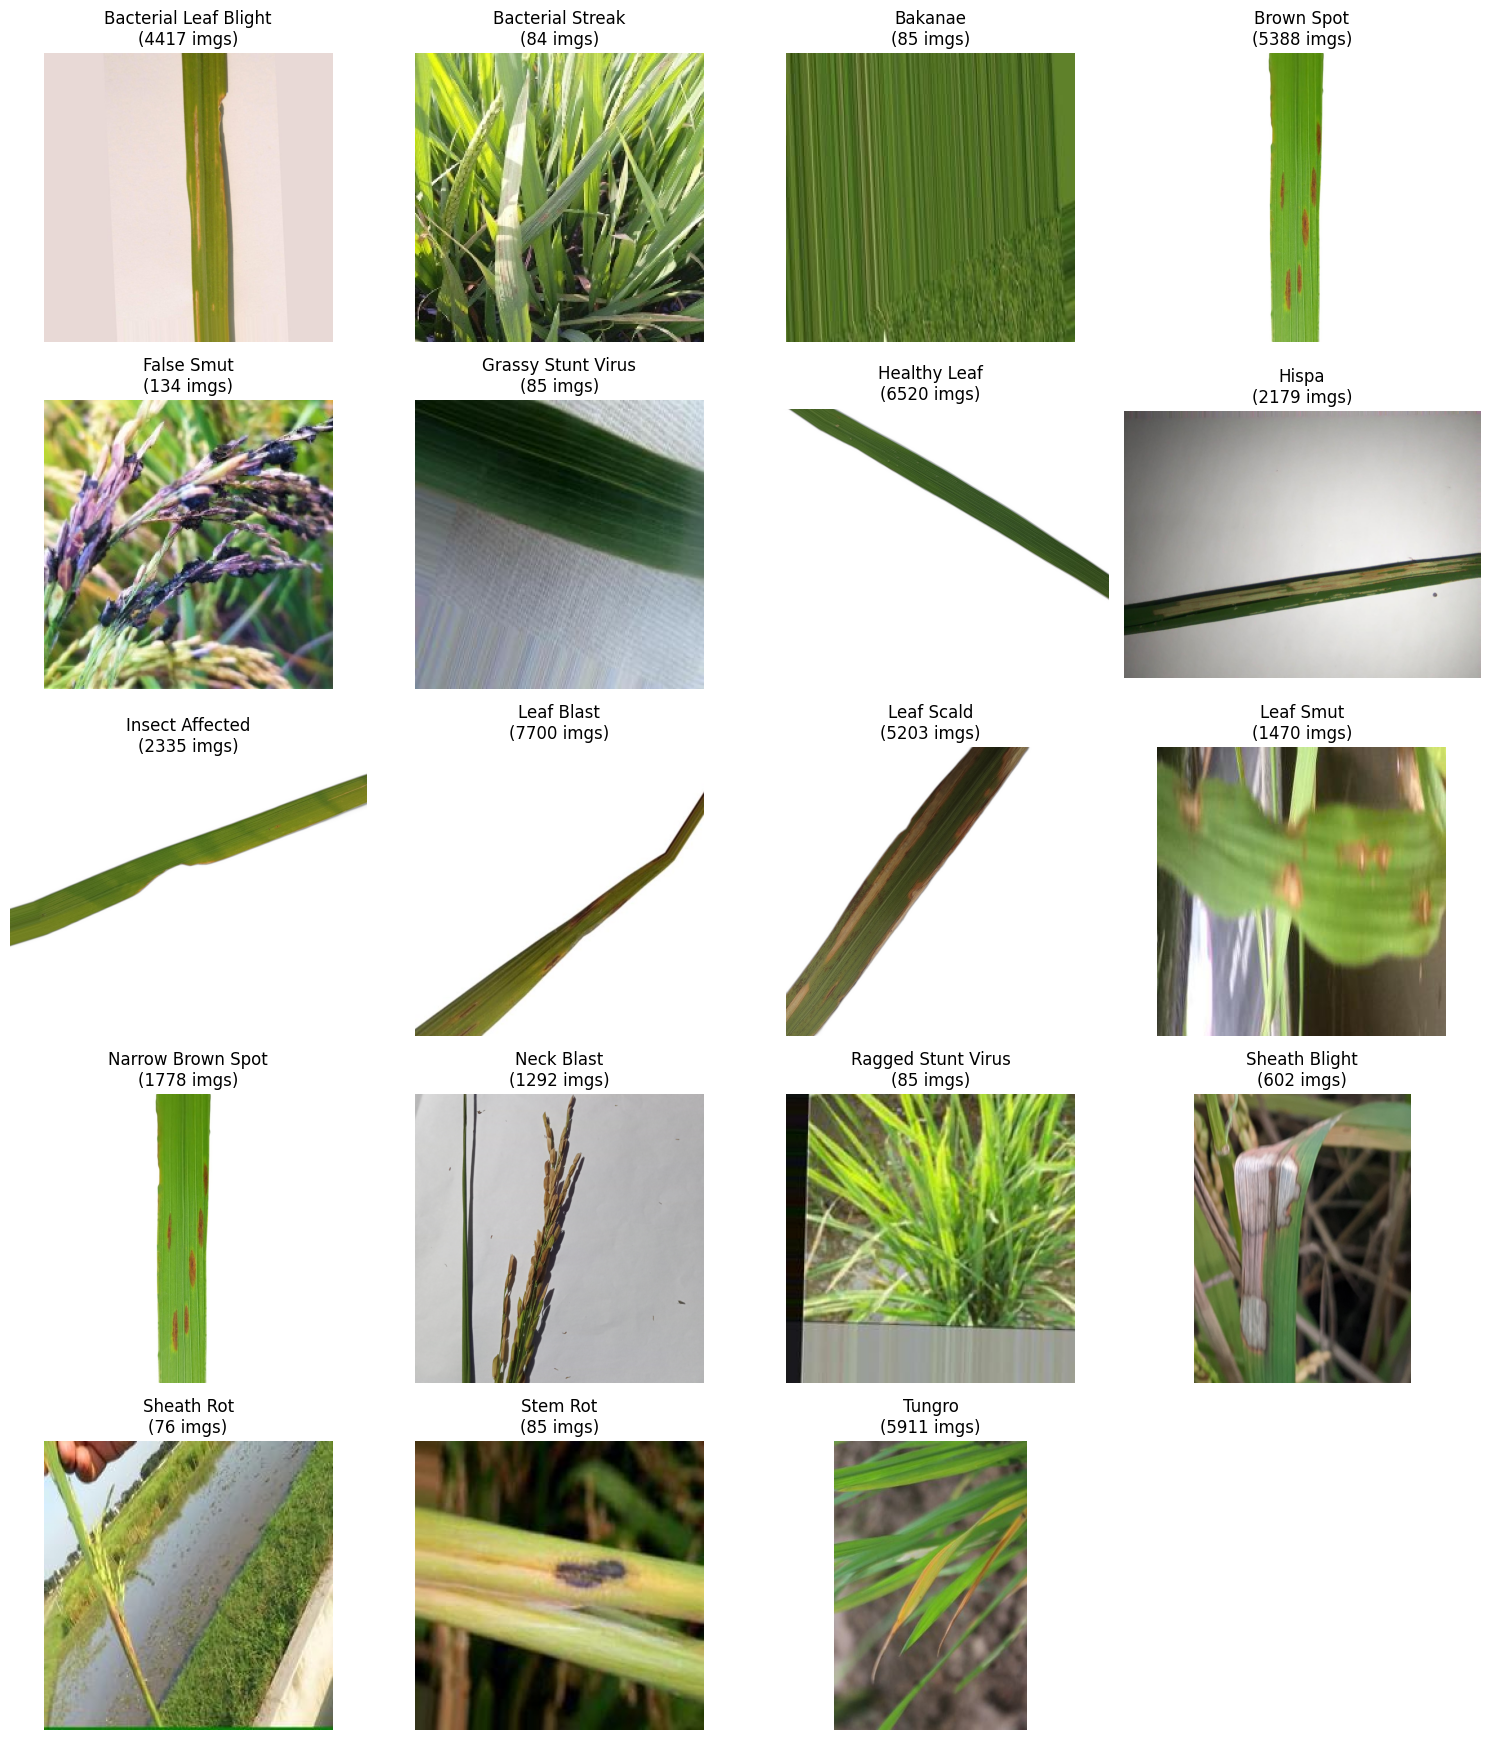


=== TEST DATASET (19 Classes) ===
Path: /kaggle/input/datasets/deepthiajith/ricedisease-testdataset/Rice Disease Dataset Test
  • Bacterial Leaf Blight | 30 images
  • Bacterial Streak     | 15 images
  • Bakanae              | 15 images
  • Brown Spot           | 30 images
  • False Smut           | 15 images
  • Grassy Stunt Virus   | 15 images
  • Healthy Leaf         | 30 images
  • Hispa                | 30 images
  • Insect Affected      | 30 images
  • Leaf Blast           | 30 images
  • Leaf Scald           | 30 images
  • Leaf Smut            | 30 images
  • Narrow Brown Spot    | 30 images
  • Neck Blast           | 30 images
  • Ragged Stunt Virus   | 15 images
  • Sheath Blight        | 30 images
  • Sheath Rot           | 15 images
  • Stem Rot             | 15 images
  • Tungro               | 30 images
TOTAL: 465 images


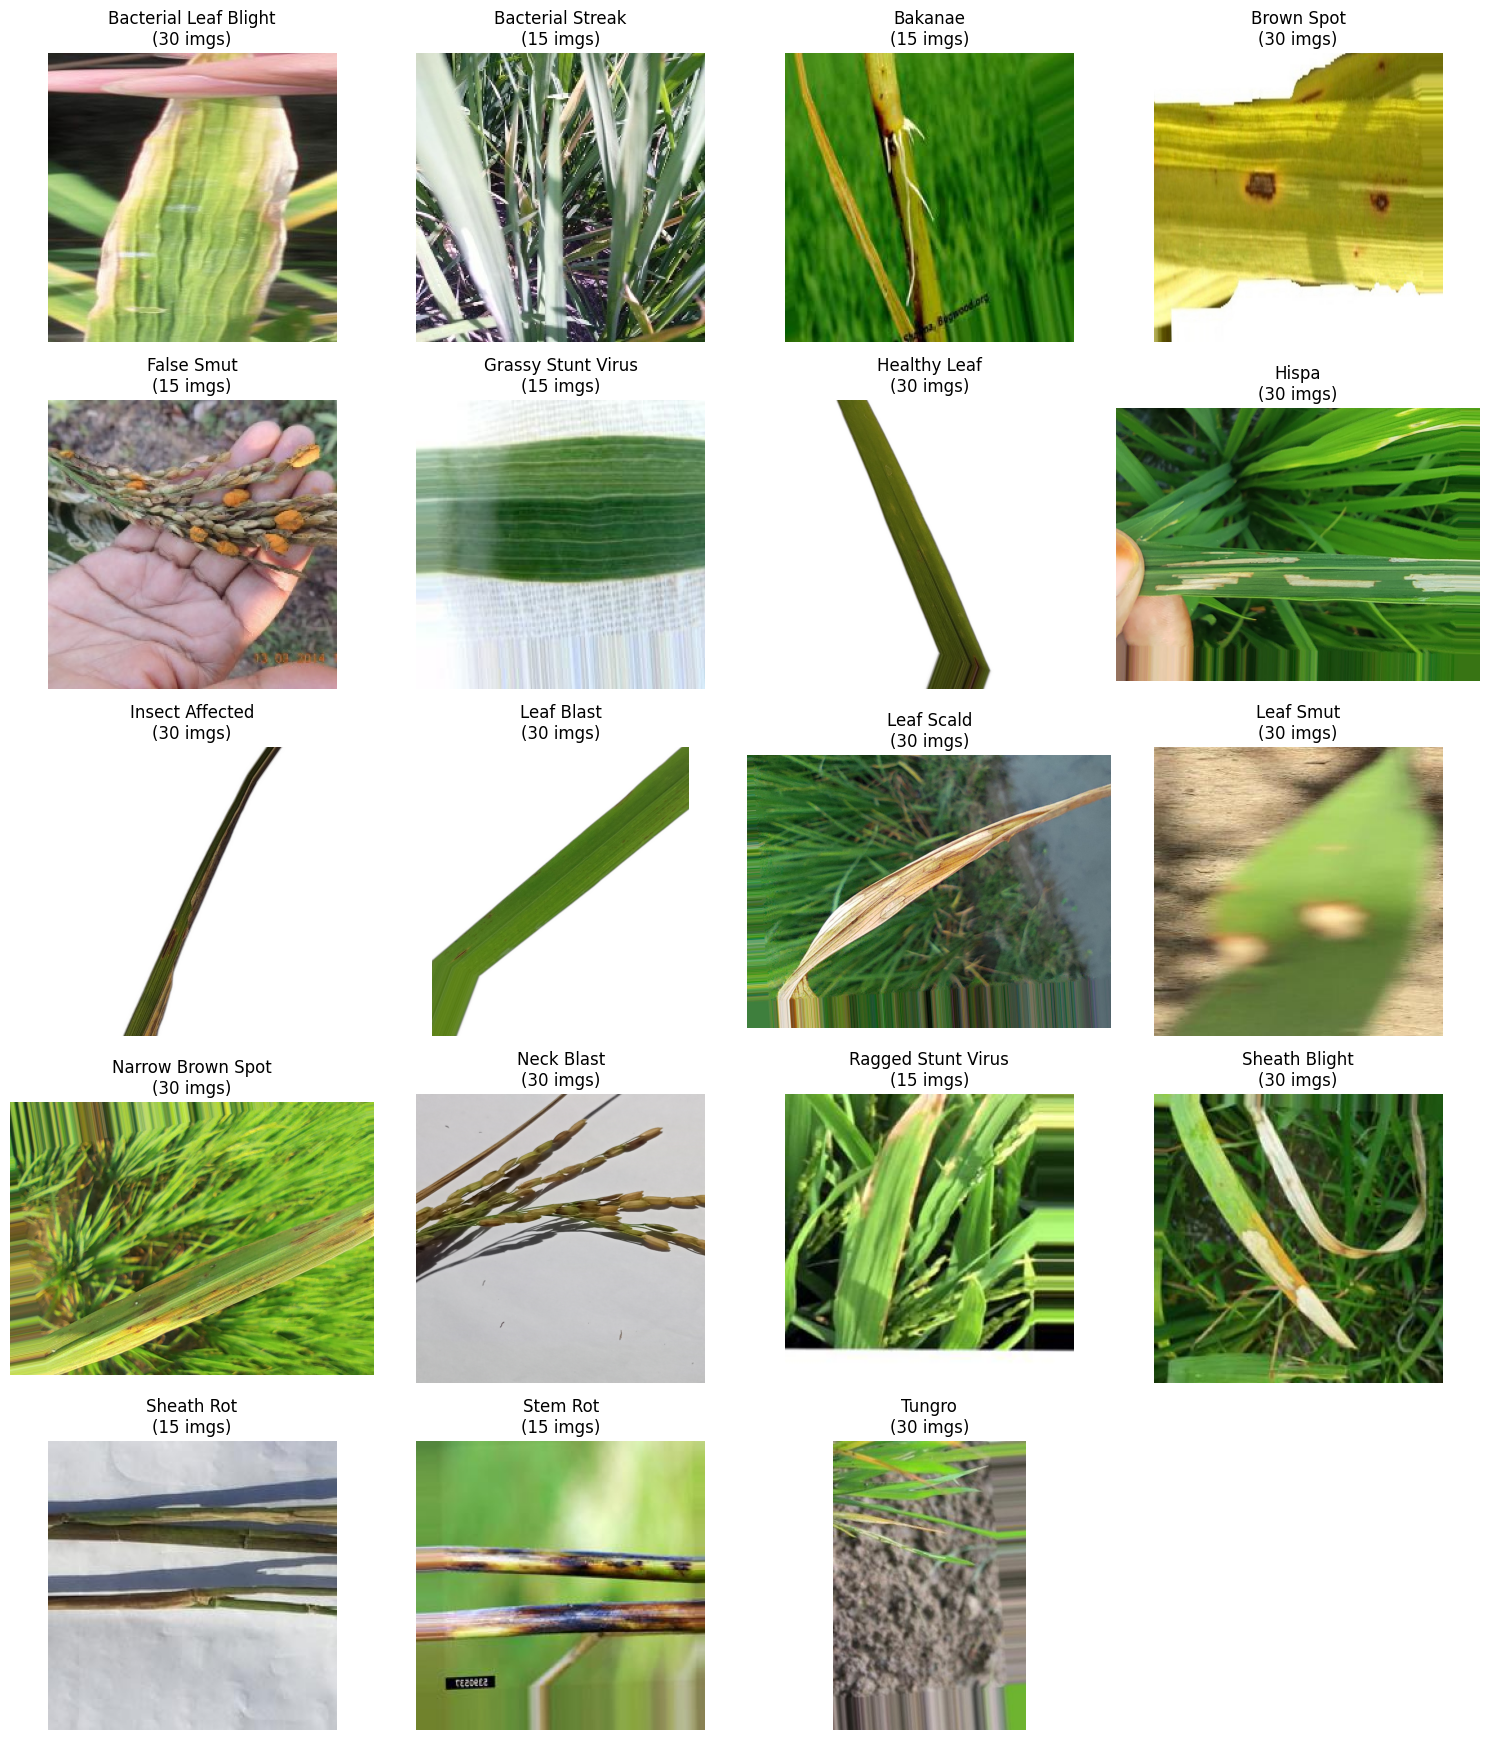

In [1]:
import os
import glob
import cv2
import math
import matplotlib.pyplot as plt

TRAIN_DIR = '/kaggle/input/datasets/deepthiajith/ricedisease-traindataset/Rice Disease Dataset'
TEST_DIR = '/kaggle/input/datasets/deepthiajith/ricedisease-testdataset/Rice Disease Dataset Test'

def inspect_and_plot(data_path, dataset_name):
    if not os.path.exists(data_path):
        # Fallback: sometimes Kaggle unzips without the parent folder
        data_path = data_path.replace('/RiceDisease-TrainDataset', '').replace('/RiceDisease-TestDataset', '')
        if not os.path.exists(data_path):
            print(f"❌ Error: Path not found: {data_path}")
            return

    # Get class folders
    classes = sorted([d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))])
    
    print(f"\n=== {dataset_name.upper()} DATASET ({len(classes)} Classes) ===")
    print(f"Path: {data_path}")
    
    # Setup Grid
    cols = 4
    rows = math.ceil(len(classes) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    if len(classes) > 1: axes = axes.flatten()
    else: axes = [axes]

    total_images = 0
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(data_path, class_name)
        images = glob.glob(os.path.join(class_path, '*.*')) # Matches jpg, png, etc.
        count = len(images)
        total_images += count
        
        print(f"  • {class_name:<20} | {count} images")

        # Plot first image
        if images:
            img = cv2.imread(images[0])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f"{class_name}\n({count} imgs)")
        else:
            axes[i].text(0.5, 0.5, "Empty", ha='center')
        
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    print(f"TOTAL: {total_images} images")
    plt.tight_layout()
    plt.show()

# Run
inspect_and_plot(TRAIN_DIR, "Train")
inspect_and_plot(TEST_DIR, "Test")

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os

class RiceDiseaseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for cls_name in self.classes:
            cls_folder = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(cls_folder):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(cls_folder, img_name))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load and Split
full_train_dataset = RiceDiseaseDataset(TRAIN_DIR, transform=train_transforms)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])
val_subset.dataset.transform = val_transforms 

test_dataset = RiceDiseaseDataset(TEST_DIR, transform=val_transforms)

# Loaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(full_train_dataset.classes)
print(f"Classes: {full_train_dataset.classes}")
print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")

Classes: ['Bacterial Leaf Blight', 'Bacterial Streak', 'Bakanae', 'Brown Spot', 'False Smut', 'Grassy Stunt Virus', 'Healthy Leaf', 'Hispa', 'Insect Affected', 'Leaf Blast', 'Leaf Scald', 'Leaf Smut', 'Narrow Brown Spot', 'Neck Blast', 'Ragged Stunt Virus', 'Sheath Blight', 'Sheath Rot', 'Stem Rot', 'Tungro']
Train: 36343 | Val: 9086 | Test: 465


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import ViTModel
from tqdm.auto import tqdm
import time
from IPython.display import FileLink, display


class ViTClassifier(nn.Module):
    def __init__(self, num_labels):
        super(ViTClassifier, self).__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        # ViT-base hidden size is 768
        self.classifier = nn.Linear(self.vit.config.hidden_size, num_labels)

    def forward(self, pixel_values):
        # Extract the CLS token
        vit_out = self.vit(pixel_values=pixel_values).last_hidden_state[:, 0, :]
        return self.classifier(vit_out)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = ViTClassifier(num_classes)
model.to(device)

EPOCHS = 10
LR = 2e-5
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

checkpoint_name = "rice_disease_vit_base.pth"
start_epoch = 0
best_acc = 0.0

# CHECKPOINT RESUME LOGIC
if os.path.exists(checkpoint_name):
    print(f"Found checkpoint: '{checkpoint_name}'. Loading...")
    
    checkpoint = torch.load(checkpoint_name, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    if 'epoch' in checkpoint:
        start_epoch = checkpoint['epoch'] + 1 
    else:
        start_epoch = 2 
        
    best_acc = checkpoint.get('accuracy', checkpoint.get('best_val_acc', 0.0))
    print(f"Resuming training for Epoch {start_epoch+1} | Previous Best Acc: {best_acc:.2f}%")
else:
    print("No checkpoint found. Starting from scratch.")


print(f"\nStarting ViT Training (Target: {EPOCHS} Epochs)...")

for epoch in range(start_epoch, EPOCHS):
    start_time = time.time()
    
    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(pixel_values=images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        
        current_acc = 100 * train_correct / train_total
        loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.1f}%")

    # VALIDATE
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Metrics
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    avg_loss = train_loss / train_total
    duration = time.time() - start_time
    
    # Save Best
    saved_tag = ""
    if val_acc > best_acc:
        best_acc = val_acc
        state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'class_names': full_train_dataset.classes, 
            'num_classes': num_classes,
            'accuracy': best_acc
        }
        torch.save(state, checkpoint_name)
        saved_tag = " [SAVED]"

    print(f"Ep {epoch+1} | {duration:.0f}s | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%{saved_tag}")
    
    if saved_tag:
        display(FileLink(checkpoint_name))

print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.2f}%")


final_checkpoint_name = "rice_disease_vit_base_final.pth"

final_state = {
    'epoch': EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names': full_train_dataset.classes, 
    'num_classes': num_classes,
    'accuracy': val_acc
}

torch.save(final_state, final_checkpoint_name)
print(f"✅ Final epoch model saved to: {final_checkpoint_name}")
display(FileLink(final_checkpoint_name))

Device: cuda


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

No checkpoint found. Starting from scratch.

Starting ViT Training (Target: 10 Epochs)...


...

Epoch 9/10:   0%|          | 0/1136 [00:00<?, ?it/s]

Ep 9 | 1395s | Loss: 0.0805 | Train Acc: 95.5% | Val Acc: 90.8%


Epoch 10/10:   0%|          | 0/1136 [00:00<?, ?it/s]

Ep 10 | 1420s | Loss: 0.0823 | Train Acc: 95.3% | Val Acc: 90.2%

Training Complete. Best Validation Accuracy: 90.93%
✅ Final epoch model saved to: rice_disease_vit_base_final.pth


/kaggle/working/rice_disease_vit_base_final.pth

EVALUATING ON TEST SET
Test Loss: 0.3992
Test Accuracy: 87.53%

DETAILED CLASSIFICATION REPORT
                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.74      0.97      0.84        30
     Bacterial Streak       1.00      0.87      0.93        15
              Bakanae       0.88      1.00      0.94        15
           Brown Spot       0.69      0.80      0.74        30
           False Smut       1.00      1.00      1.00        15
   Grassy Stunt Virus       1.00      0.80      0.89        15
         Healthy Leaf       0.84      0.87      0.85        30
                Hispa       0.93      0.93      0.93        30
      Insect Affected       0.97      0.93      0.95        30
           Leaf Blast       0.64      1.00      0.78        30
           Leaf Scald       0.97      1.00      0.98        30
            Leaf Smut       1.00      0.47      0.64        30
    Narrow Brown Spot       0.83      0.80      0.81        30
           Neck Blast 

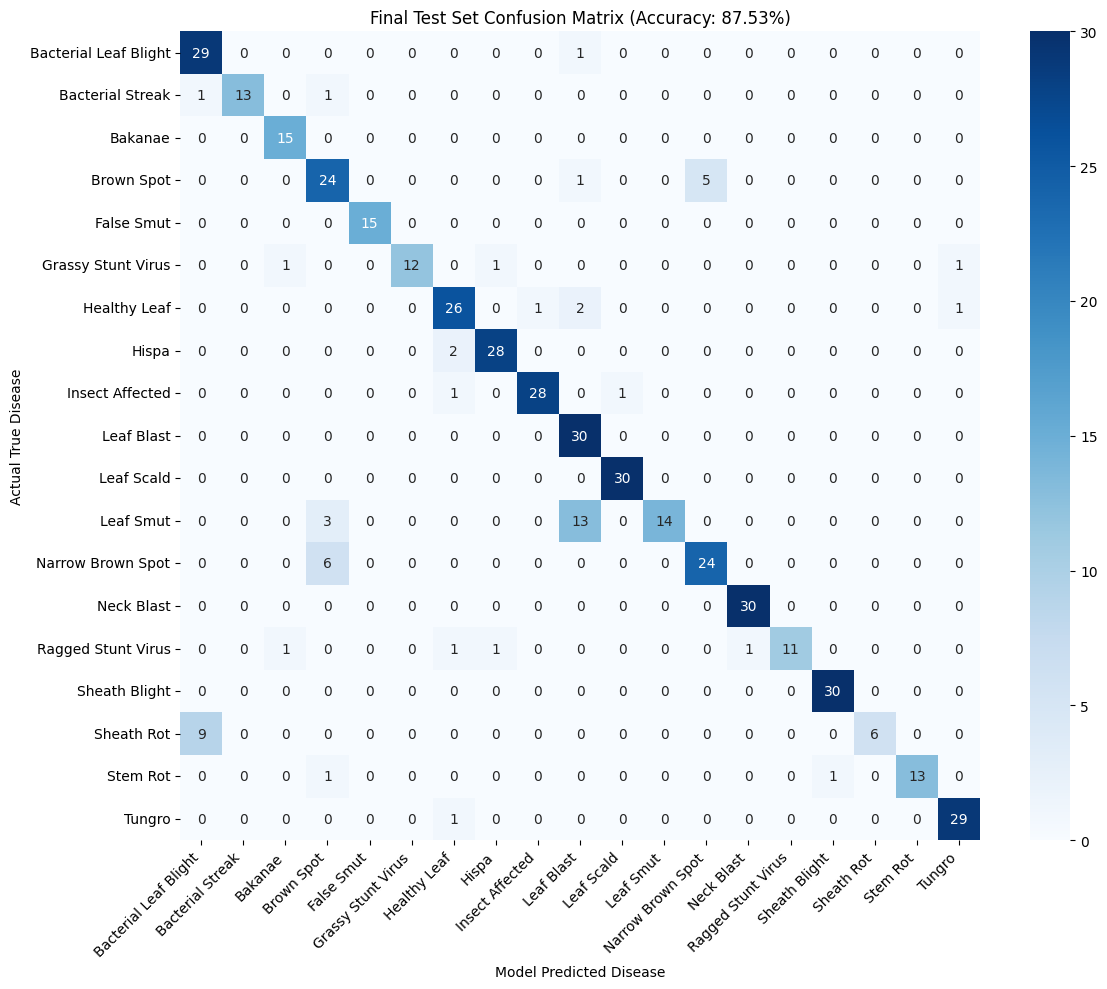

In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

print("EVALUATING ON TEST SET")

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(pixel_values=images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        
        # Store for detailed metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall metrics
final_test_acc = 100 * test_correct / test_total
final_test_loss = test_loss / test_total

print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%\n")

class_names = test_dataset.classes

print("DETAILED CLASSIFICATION REPORT")

# Need to check for recall on the minority classes
print(classification_report(all_labels, all_preds, target_names=class_names))


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.ylabel('Actual True Disease')
plt.xlabel('Model Predicted Disease')
plt.title(f'Final Test Set Confusion Matrix (Accuracy: {final_test_acc:.2f}%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()